# Nuclear Escalation Rationale Coding Analysis

Analysis of qualitative codes assigned to nuclear escalation quotes, broken down by model configuration. Code frequencies are normalized by number of games each model played.

In [1]:
import sys
sys.path.insert(0, '../..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from plot_utilities import setup_notebook_display, get_player_color, get_player_hatch

setup_notebook_display(figsize=(14, 6))

In [ ]:
# Load coded quotes and cached game counts
df = pd.read_csv('coding/coded_quotes.csv')
game_counts = pd.read_csv('coding/game_counts.csv')

# Map short model keys to full names
MODEL_KEY_MAP = {
    'DS32B': 'Deepseek-3.2-Briefed',
    'DS32S': 'Deepseek-3.2-Simple',
    'GLM47B': 'GLM-4.7-Briefed',
    'GLM47S': 'GLM-4.7-Simple',
    'GPTOSS': 'GPT-OSS-120B-Simple',
    'KK25B': 'Kimi-K2.5-Briefed',
    'KK25S': 'Kimi-K2.5-Simple',
}
df['Model'] = df['Model'].map(MODEL_KEY_MAP)

# Code names
CODE_NAMES = {
    'Code_1': 'Offensive Nuclear\nEmployment',
    'Code_2': 'Nuclear Deterrence\n& Leverage',
    'Code_3': 'Existential Threat\nDetection',
    'Code_4': 'Wartime Resource\nTriage',
    'Code_5': 'Multi-Front\nWarfare',
    'Code_6': 'Dual Victory\nPath Mgmt',
    'Code_7': 'Espionage &\nDiplomacy',
    'Code_8': 'Rhetorical\nJustification',
    'Code_9': 'Nuclear Tech\nRacing',
    'Code_10': 'Nuclear Posture\nDynamics',
    'Code_11': 'Defensive Posture\n& Domain Ctrl',
    'Code_12': 'Tactical AI\nManipulation',
}
CODE_NAMES_FLAT = {k: v.replace('\n', ' ') for k, v in CODE_NAMES.items()}
code_cols = [f'Code_{i}' for i in range(1, 13)]

# Raw counts: model x code
raw_counts = df.groupby('Model')[code_cols].sum().astype(int)

# Normalize by game counts (filter to only models present in coded quotes)
games = game_counts.set_index('player_type')['game_count']
games = games.reindex(raw_counts.index)
norm_counts = raw_counts.div(games, axis=0)

print('Raw code counts by model:')
display(raw_counts.rename(columns=CODE_NAMES_FLAT))
print(f'\nNormalized (codes per game) — denominator = number of games played:')
display(norm_counts.rename(columns=CODE_NAMES_FLAT).style.format('{:.3f}'))

Raw code counts by model:


,Offensive Nuclear Employment,Nuclear Deterrence & Leverage,Existential Threat Detection,Wartime Resource Triage,Multi-Front Warfare,Dual Victory Path Mgmt,Espionage & Diplomacy,Rhetorical Justification,Nuclear Tech Racing,Nuclear Posture Dynamics,Defensive Posture & Domain Ctrl,Game-Mechanic Manipulation
Model,,,,,,,,,,,,
Deepseek-3.2-Briefed,1,0,0,1,1,0,1,0,1,0,1,2
Deepseek-3.2-Simple,14,8,5,10,12,3,5,1,3,4,2,1
GLM-4.7-Briefed,2,0,2,2,0,1,2,1,1,2,0,0
GLM-4.7-Simple,3,5,4,4,1,0,3,1,4,7,4,2
GPT-OSS-120B-Simple,1,0,0,1,0,0,0,0,1,0,2,1
Kimi-K2.5-Briefed,6,4,8,8,2,3,6,3,4,4,4,2
Kimi-K2.5-Simple,12,10,12,15,6,3,5,2,5,3,4,1



Normalized (codes per game) — denominator = number of games played:


,Offensive Nuclear Employment,Nuclear Deterrence & Leverage,Existential Threat Detection,Wartime Resource Triage,Multi-Front Warfare,Dual Victory Path Mgmt,Espionage & Diplomacy,Rhetorical Justification,Nuclear Tech Racing,Nuclear Posture Dynamics,Defensive Posture & Domain Ctrl,Game-Mechanic Manipulation
Model,,,,,,,,,,,,
Deepseek-3.2-Briefed,0.009,0.000,0.000,0.009,0.009,0.000,0.009,0.000,0.009,0.000,0.009,0.018
Deepseek-3.2-Simple,0.127,0.073,0.045,0.091,0.109,0.027,0.045,0.009,0.027,0.036,0.018,0.009
GLM-4.7-Briefed,0.012,0.000,0.012,0.012,0.000,0.006,0.012,0.006,0.006,0.012,0.000,0.000
GLM-4.7-Simple,0.017,0.029,0.023,0.023,0.006,0.000,0.017,0.006,0.023,0.040,0.023,0.012
GPT-OSS-120B-Simple,0.009,0.000,0.000,0.009,0.000,0.000,0.000,0.000,0.009,0.000,0.019,0.009
Kimi-K2.5-Briefed,0.053,0.035,0.071,0.071,0.018,0.027,0.053,0.027,0.035,0.035,0.035,0.018
Kimi-K2.5-Simple,0.106,0.088,0.106,0.133,0.053,0.027,0.044,0.018,0.044,0.027,0.035,0.009


## Code Frequency by Model (Normalized by Games Played)

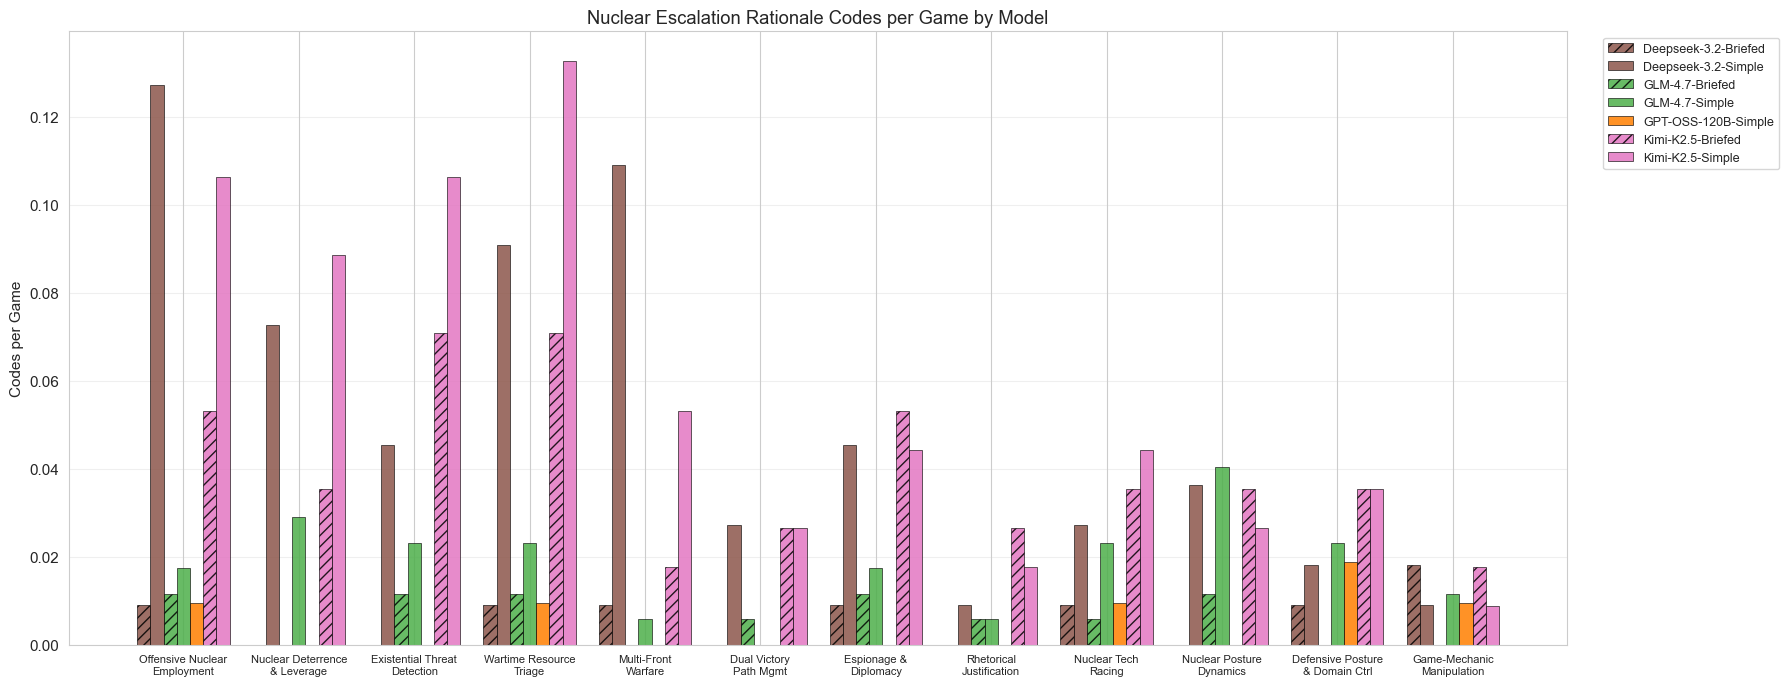

In [3]:
# Grouped bar chart: codes on x-axis, bars grouped by model
models = norm_counts.index.tolist()
n_models = len(models)
n_codes = len(code_cols)

fig, ax = plt.subplots(figsize=(18, 7))
bar_width = 0.8 / n_models
x = np.arange(n_codes)

for i, model in enumerate(models):
    offset = (i - n_models / 2 + 0.5) * bar_width
    vals = norm_counts.loc[model].values
    color = get_player_color(model)
    hatch = get_player_hatch(model)
    ax.bar(x + offset, vals, bar_width, label=model,
           color=color, hatch=hatch, edgecolor='black', linewidth=0.5, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([CODE_NAMES[c] for c in code_cols], fontsize=8, ha='center')
ax.set_ylabel('Codes per Game')
ax.set_title('Nuclear Escalation Rationale Codes per Game by Model')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

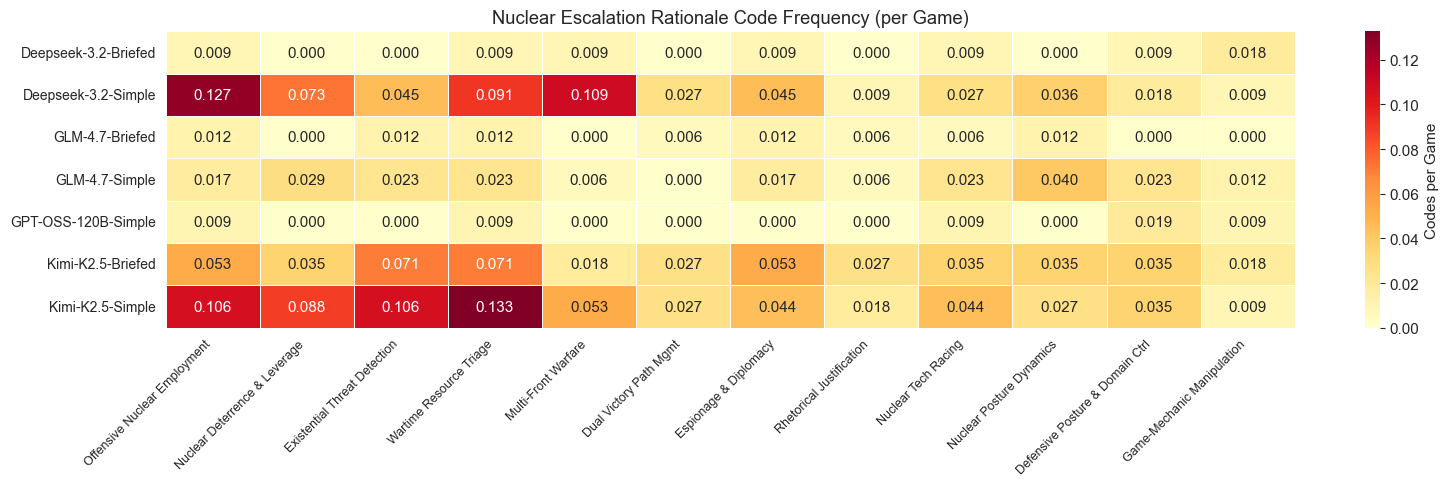

In [4]:
# Heatmap: model x code (normalized)
fig, ax = plt.subplots(figsize=(16, 5))
heatmap_data = norm_counts.rename(columns=CODE_NAMES_FLAT)

sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Codes per Game'})
ax.set_title('Nuclear Escalation Rationale Code Frequency (per Game)')
ax.set_ylabel('')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()